In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from torchvision.models import resnet18
import torch.fft
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2


(1, 150, 150)


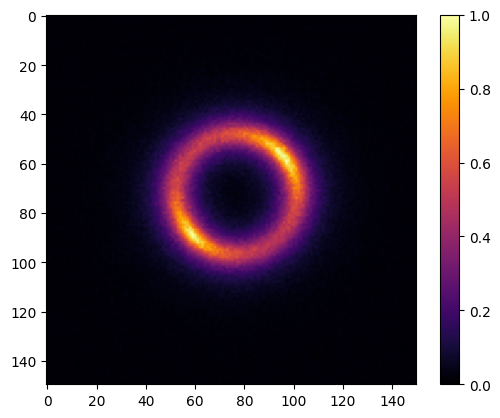

In [3]:
sample_path = "/Users/ishaan/Documents/DeepLense/dataset/train/no"

file = os.listdir(sample_path)[0]

image = np.load(os.path.join(sample_path, file))

print(image.shape)

plt.imshow(image.squeeze(0), cmap="inferno")
plt.colorbar()
plt.show()

In [4]:
class_map = {
    "no": 0,
    "sphere": 1,
    "vort": 2
}

In [5]:
class AddGaussianNoise(torch.nn.Module):
    def __init__(self, mean=0., std=0.05):
        super().__init__()
        self.mean = mean
        self.std = std

    def forward(self, tensor):
        noise = torch.randn(tensor.size()) * self.std + self.mean
        return tensor + noise

In [6]:


class LensDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.samples = []
        self.labels = []
        self.transform = transform
        for cls in class_map.keys():
            folder = os.path.join(root_dir, cls)
            if not os.path.exists(folder): continue
            
            for file in os.listdir(folder):
                if file.endswith(".npy"):
                    path = os.path.join(folder, file)
                    self.samples.append(path)
                    self.labels.append(class_map[cls])

    def __len__(self):
        return len(self.samples)


    def __getitem__(self, idx):
        
        image = np.load(self.samples[idx])
        image_tensor = torch.tensor(image, dtype=torch.float32)
        
        if image_tensor.dim() > 2:
            image_tensor = image_tensor.squeeze()

        image_tensor = image_tensor.unsqueeze(0)

        image_tensor = torch.log1p(image_tensor - image_tensor.min())
        mean = image_tensor.mean()
        std = image_tensor.std()
        image_tensor = (image_tensor - mean) / (std + 1e-8)

        if self.transform:
            image_tensor = self.transform(image_tensor)

        image_2d = image_tensor.squeeze(0)

        fft_complex = torch.fft.fftshift(torch.fft.fft2(image_2d))
        fft_magnitude = torch.log(torch.abs(fft_complex) + 1e-8) 
        fft_magnitude = fft_magnitude.unsqueeze(0)
        combined_tensor = torch.cat((image_tensor, fft_magnitude), dim=0)

        label = self.labels[idx]
        return combined_tensor, label

In [11]:
class AddGaussianNoise(torch.nn.Module):
    def __init__(self, mean=0., std=0.05):
        super().__init__()
        self.mean = mean
        self.std = std

    def forward(self, tensor):
        noise = torch.randn(tensor.size()) * self.std + self.mean
        return tensor + noise
    
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    
    v2.RandomAffine(
        degrees=(0, 360),
        translate=(0.1, 0.1),
        fill=0
    ),
    
    AddGaussianNoise(mean=0., std=0.05) 
])

val_transforms = None

In [12]:
from torch.utils.data import DataLoader

train_dataset = LensDataset("/Users/ishaan/Documents/DeepLense/dataset/train")
val_dataset = LensDataset("/Users/ishaan/Documents/DeepLense/dataset/val")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [13]:
import torch.nn as nn
import torchvision.models as models

def get_model():

    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    original_weights = model.conv1.weight.clone()

    model.conv1 = nn.Conv2d(
        in_channels=2, 
        out_channels=64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )
    
    with torch.no_grad():
        model.conv1.weight[:, 0:1, :, :] = original_weights[:, 0:1, :, :]
        model.conv1.weight[:, 1:2, :, :] = original_weights[:, 1:2, :, :]

    model.fc = nn.Linear(512, 3)

    return model

In [16]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {device}")
model = get_model().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Training on: mps


In [17]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 1028.0303148627281
Epoch: 1 Loss: 975.192518055439
Epoch: 2 Loss: 951.5957874059677
Epoch: 3 Loss: 931.0534038543701
Epoch: 4 Loss: 912.8700950145721
Epoch: 5 Loss: 893.3519491553307
Epoch: 6 Loss: 867.6321563720703
Epoch: 7 Loss: 840.2150906324387
Epoch: 8 Loss: 799.5266679525375
Epoch: 9 Loss: 728.3257957100868


In [18]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

In [19]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu())
        all_labels.append(labels)

all_probs = torch.cat(all_probs)
all_labels = torch.cat(all_labels)

In [20]:
y_true = all_labels.numpy()
y_score = all_probs.numpy()

y_true_bin = label_binarize(y_true, classes=[0,1,2])

auc = roc_auc_score(y_true_bin, y_score, multi_class="ovr")

print("AUC Score:", auc)

AUC Score: 0.6988644533333334


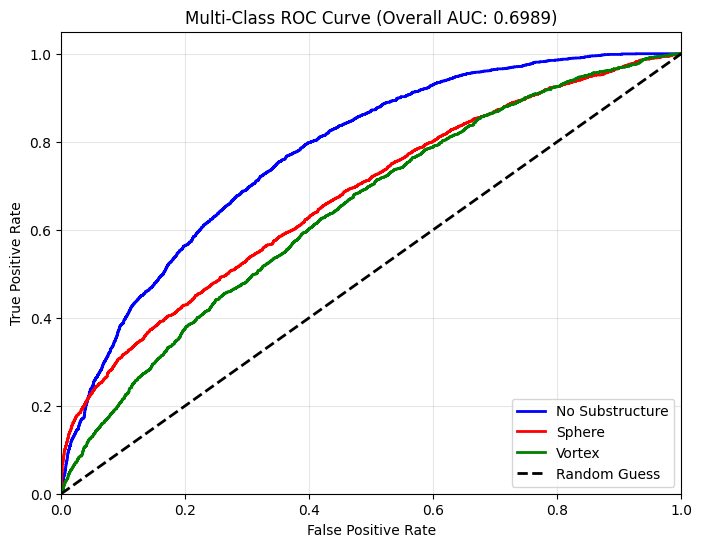

In [21]:
from sklearn.metrics import roc_curve
classes = ['No Substructure', 'Sphere', 'Vortex']
colors = ['blue', 'red', 'green']

plt.figure(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{classes[i]}')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Multi-Class ROC Curve (Overall AUC: {auc:.4f})')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()